In [3]:
import pandas as pd

file_path = "/content/campus_placement_data.csv"
df = pd.read_csv(file_path)
print(df.head())

  student_id  gender  age city_tier  ssc_percentage ssc_board  hsc_percentage  \
0  STU000001    Male   22    Tier 1           71.01     State           76.76   
1  STU000002  Female   22    Tier 2           58.46      CBSE           57.62   
2  STU000003  Female   21    Tier 1           67.83      CBSE           65.67   
3  STU000004  Female   21    Tier 2           80.40      CBSE           77.15   
4  STU000005    Male   21    Tier 1           66.10     State           62.81   

  hsc_board hsc_stream  degree_percentage  ... technical_skills_score  \
0      CBSE   Commerce              64.44  ...                    6.8   
1     State    Science              68.24  ...                    4.6   
2     State   Commerce              52.33  ...                    4.7   
3     State    Science              56.55  ...                    6.8   
4      ICSE    Science              78.93  ...                    7.0   

   soft_skills_score aptitude_score  communication_score  \
0             

### Data Cleaning and Preprocessing

First, let's check for any missing values in the dataset and inspect the data types of each column.

In [4]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])


Missing values in each column:
specialization                5446
leadership_roles                 1
extracurricular_activities       1
backlogs                         1
placed                           1
salary_lpa                       1
dtype: int64


In [5]:
# Display data types and non-null counts
print("\nDataFrame Info:")
df.info()



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8439 entries, 0 to 8438
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  8439 non-null   object 
 1   gender                      8439 non-null   object 
 2   age                         8439 non-null   int64  
 3   city_tier                   8439 non-null   object 
 4   ssc_percentage              8439 non-null   float64
 5   ssc_board                   8439 non-null   object 
 6   hsc_percentage              8439 non-null   float64
 7   hsc_board                   8439 non-null   object 
 8   hsc_stream                  8439 non-null   object 
 9   degree_percentage           8439 non-null   float64
 10  degree_field                8439 non-null   object 
 11  mba_percentage              8439 non-null   float64
 12  specialization              2993 non-null   object 
 13  internships_coun

In [6]:
# Fill missing values in 'specialization' with 'Unknown'
df['specialization'] = df['specialization'].fillna('Unknown')
print("Missing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Display the value counts for 'specialization' to see the distribution
print("\nValue counts for 'specialization' after imputation:")
print(df['specialization'].value_counts())

Missing values after imputation:
leadership_roles              1
extracurricular_activities    1
backlogs                      1
placed                        1
salary_lpa                    1
dtype: int64

Value counts for 'specialization' after imputation:
specialization
Unknown                5446
Marketing & Finance    1008
Marketing & HR          993
Finance & HR            992
Name: count, dtype: int64


### Data Exploration (EDA)

Let's start by looking at the descriptive statistics of the numerical columns to get a general overview of the data distribution, central tendency, and spread.

In [7]:
# Display descriptive statistics for numerical columns
print("Descriptive Statistics for Numerical Columns:")
print(df.describe())


Descriptive Statistics for Numerical Columns:
               age  ssc_percentage  hsc_percentage  degree_percentage  \
count  8439.000000     8439.000000     8439.000000        8439.000000   
mean     21.549947       71.810015       71.774770          70.184304   
std       1.508791       11.828925       13.822278          15.451738   
min      18.000000       40.000000       40.000000          45.000000   
25%      21.000000       63.820000       62.190000          58.350000   
50%      21.000000       71.800000       71.850000          69.800000   
75%      22.000000       79.890000       81.360000          81.560000   
max      26.000000      100.000000      100.000000         100.000000   

       mba_percentage  internships_count  projects_count  \
count     8439.000000        8439.000000     8439.000000   
mean        23.125021           1.669511        3.317810   
std         31.681227           1.298041        1.881524   
min          0.000000           0.000000        0.000000

Now, let's visualize the distribution of some key numerical variables, starting with `salary_lpa` and `age`.

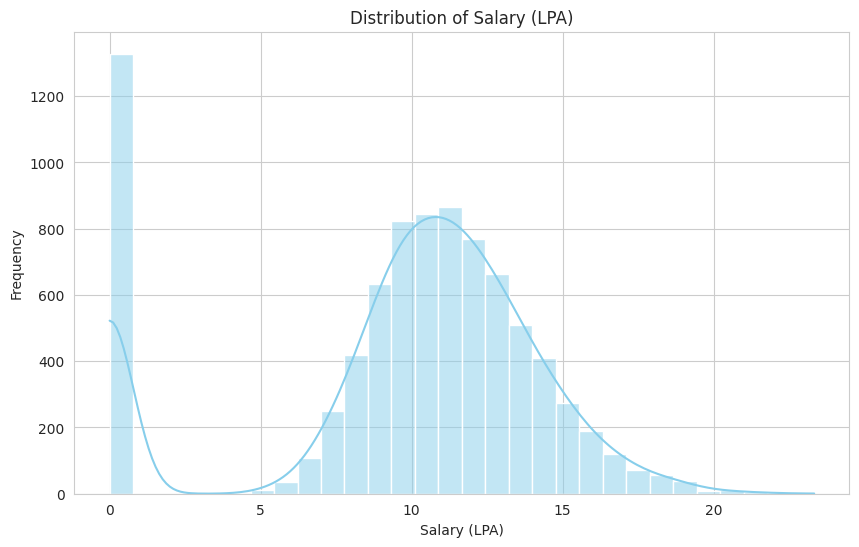

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Distribution of Salary (salary_lpa)
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_lpa'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Salary (LPA)')
plt.xlabel('Salary (LPA)')
plt.ylabel('Frequency')
plt.show()


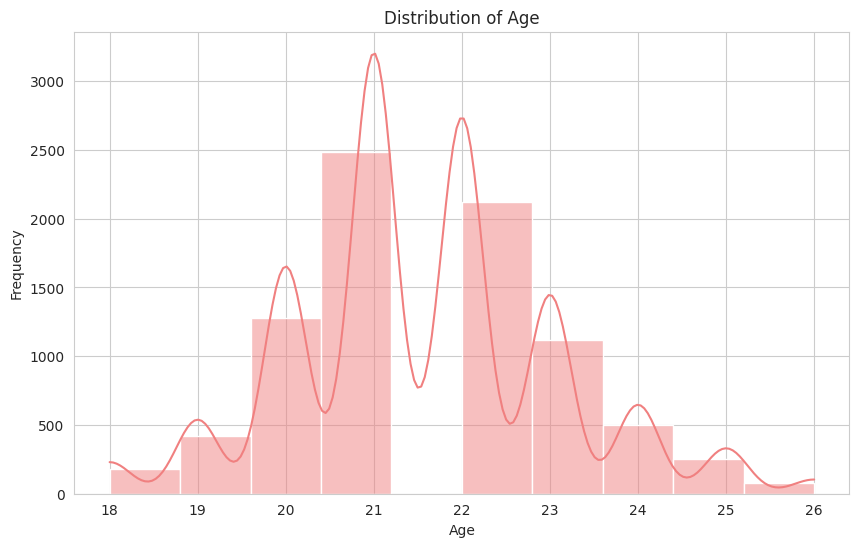

In [9]:
# Distribution of Age
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], kde=True, bins=10, color='lightcoral')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


Next, let's look at the distribution of categorical variables, such as `gender`.

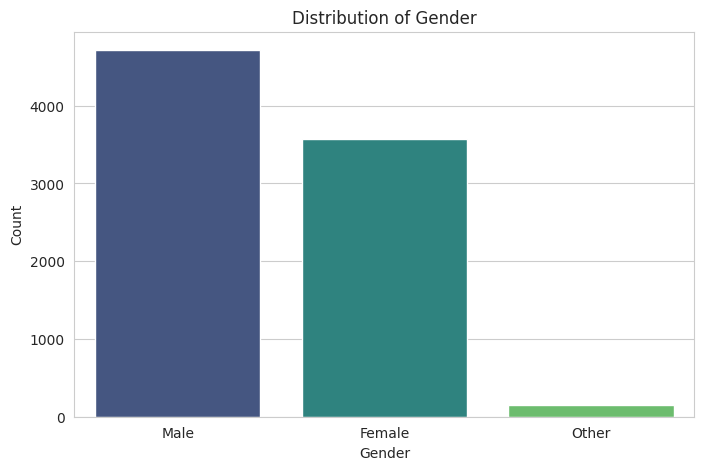

In [10]:
# Distribution of Gender
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', data=df, palette='viridis', hue='gender', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Feature Engineering

We'll create some new features that could potentially improve the predictive power of our model. This includes combining related scores and creating binary indicators for certain attributes.

In [11]:
# Create a combined 'Total_Score' from various skill and aptitude scores
df['total_score'] = df['technical_skills_score'] + df['soft_skills_score'] + df['aptitude_score'] + df['communication_score']

# Create a binary feature for students who have an MBA (mba_percentage > 0)
df['has_mba'] = (df['mba_percentage'] > 0).astype(int)

# Create a binary feature for students with work experience (work_experience_months > 0)
df['has_work_experience'] = (df['work_experience_months'] > 0).astype(int)

print("New features created: 'total_score', 'has_mba', 'has_work_experience'")
print(df[['total_score', 'has_mba', 'has_work_experience']].head())

New features created: 'total_score', 'has_mba', 'has_work_experience'
   total_score  has_mba  has_work_experience
0         82.9        0                    1
1         75.3        0                    1
2         73.6        0                    1
3         57.7        0                    1
4         72.1        0                    1


### Categorical Feature Encoding

Many machine learning models require numerical input. We need to convert our categorical features into a numerical format, which can be done using one-hot encoding.

In [12]:
# Identify categorical columns for one-hot encoding (excluding student_id and placed/salary_lpa as they are target/identifier or already numerical)
categorical_cols = ['gender', 'city_tier', 'ssc_board', 'hsc_board', 'hsc_stream', 'degree_field', 'specialization']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape of DataFrame after one-hot encoding:", df_encoded.shape)
print("Columns after encoding:", df_encoded.columns.tolist())

# Display the first few rows of the encoded DataFrame
print(df_encoded.head())

Shape of DataFrame after one-hot encoding: (8439, 39)
Columns after encoding: ['student_id', 'age', 'ssc_percentage', 'hsc_percentage', 'degree_percentage', 'mba_percentage', 'internships_count', 'projects_count', 'certifications_count', 'technical_skills_score', 'soft_skills_score', 'aptitude_score', 'communication_score', 'work_experience_months', 'leadership_roles', 'extracurricular_activities', 'backlogs', 'placed', 'salary_lpa', 'total_score', 'has_mba', 'has_work_experience', 'gender_Male', 'gender_Other', 'city_tier_Tier 2', 'city_tier_Tier 3', 'ssc_board_ICSE', 'ssc_board_State', 'hsc_board_ICSE', 'hsc_board_State', 'hsc_stream_Commerce', 'hsc_stream_Science', 'degree_field_Business', 'degree_field_Engineering', 'degree_field_Other', 'degree_field_Science', 'specialization_Marketing & Finance', 'specialization_Marketing & HR', 'specialization_Unknown']
  student_id  age  ssc_percentage  hsc_percentage  degree_percentage  \
0  STU000001   22           71.01           76.76      

### Feature Selection

Now, let's perform some basic feature selection by looking at the correlation of numerical features with our target variable, `salary_lpa`. This will help us understand which features have a linear relationship with salary.

In [13]:
# Calculate correlations with 'salary_lpa'
correlations = df_encoded.corr(numeric_only=True)['salary_lpa'].sort_values(ascending=False)

print("Correlations with Salary (LPA):")
print(correlations)

# Filter features based on a correlation threshold
# We'll use an absolute correlation threshold of 0.1 as a starting point
# and exclude 'salary_lpa' itself and 'student_id'
selected_features = correlations[abs(correlations) > 0.1].index.tolist()
selected_features = [f for f in selected_features if f not in ['salary_lpa', 'student_id', 'placed']]

print(f"\nSelected features based on |correlation| > 0.1 with salary_lpa (excluding 'salary_lpa', 'student_id', 'placed'):")
print(selected_features)

# Prepare the final feature set for modeling
X = df_encoded[selected_features]
y = df_encoded['salary_lpa']

print("\nShape of X (features) after selection:", X.shape)
print("Shape of y (target):", y.shape)

Correlations with Salary (LPA):
salary_lpa                            1.000000
placed                                0.870621
work_experience_months                0.320307
degree_percentage                     0.312362
hsc_percentage                        0.311261
technical_skills_score                0.291331
ssc_percentage                        0.287546
has_work_experience                   0.277943
soft_skills_score                     0.270627
communication_score                   0.255425
total_score                           0.212372
internships_count                     0.211974
certifications_count                  0.126807
aptitude_score                        0.124922
degree_field_Engineering              0.102647
extracurricular_activities            0.041452
degree_field_Business                 0.038296
projects_count                        0.029622
leadership_roles                      0.017395
specialization_Marketing & HR         0.015348
has_mba                     

### Model Training and Evaluation

Now that our features (`X`) and target (`y`) are prepared, we will proceed with model training and evaluation. We'll split the data, train a few different regression models, and then evaluate their performance using appropriate metrics.

In [14]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (6751, 15)
X_test shape: (1688, 15)
y_train shape: (6751,)
y_test shape: (1688,)


#### 1. Linear Regression Model

Let's start with a simple Linear Regression model as a baseline.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_model.predict(X_test)

# Evaluate the Linear Regression model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Model Performance:")
print(f"  Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"  Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"  R-squared (R2): {r2_lr:.2f}")

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

#### 2. Decision Tree Regressor Model

Let's try a Decision Tree Regressor to see if a non-linear model can capture more patterns in the data.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the Decision Tree Regressor model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor Model Performance:")
print(f"  Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"  Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_dt:.2f}")
print(f"  R-squared (R2): {r2_dt:.2f}")

#### 2. Decision Tree Regressor Model

Let's try a Decision Tree Regressor to see if a non-linear model can capture more patterns in the data.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the Decision Tree Regressor model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor Model Performance:")
print(f"  Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"  Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_dt:.2f}")
print(f"  R-squared (R2): {r2_dt:.2f}")

#### 3. Random Forest Regressor Model

Given the performance of the Decision Tree, let's try a Random Forest Regressor, an ensemble method that typically offers improved accuracy and generalization by combining multiple decision trees.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest Regressor model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Model Performance:")
print(f"  Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"  R-squared (R2): {r2_rf:.2f}")

#### Predicted vs Actual Values Visualization

### Save the Best Model

Now that we have evaluated the models, let's save the Random Forest Regressor model (which performed well, despite Linear Regression having a slightly higher R2 in this instance) for future use. We will use the `pickle` library for this.

In [ ]:
import pickle

# Define the filename for the model
model_filename = 'Model.pkl'

# Save the Random Forest Regressor model to the file
with open(model_filename, 'wb') as file:
    pickle.dump(rf_model, file)

print(f"Random Forest Regressor model saved successfully as '{model_filename}'")

In [17]:
print(X_train)

      work_experience_months  degree_percentage  hsc_percentage  \
4319                       7              59.47           59.82   
8015                      31              62.69           57.11   
7538                       0              83.14           76.70   
7061                       0              45.00           44.63   
1253                       0              82.99           86.01   
...                      ...                ...             ...   
5734                      17              64.05           64.95   
5191                      10              72.65           65.88   
5390                       0              82.46           67.47   
860                        0              45.00           49.13   
7270                       8              73.30           72.01   

      technical_skills_score  ssc_percentage  has_work_experience  \
4319                    10.0           73.52                    1   
8015                     4.3           72.41             